<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EC%9D%91%EC%9A%A9_11%EC%B0%A8%EC%8B%9C_03_Faster_R_CNN_Fine_tuning_%EC%8B%A4%EB%AC%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# Penn-Fudan Pedestrian Detection Dataset 사용
# 환경 설정 및 필수 라이브러리
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms as T
import torch.utils.data as data
from torch.utils.data import DataLoader


import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import os
import time
from pathlib import Path
from tqdm import tqdm
import zipfile
import urllib.request
import shutil


print(f'PyTorch: {torch.__version__}')
print(f'TorchVision: {torchvision.__version__}')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch: 2.10.0+cu128
TorchVision: 0.25.0+cu128
Device: cuda
GPU: NVIDIA L4
GPU Memory: 23.66 GB


데이터셋이 이미 존재합니다: PennFudanPed

=== 데이터셋 구조 ===
이미지: 170개
마스크: 170개


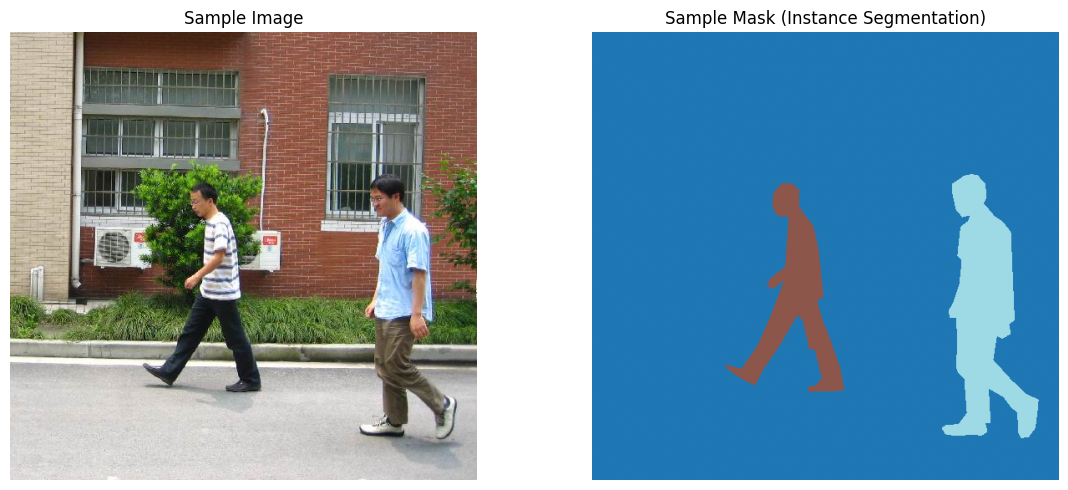

In [44]:
# 데이터셋 다운로드 및 준비
def download_pennfudan_dataset():
    """Penn-Fudan Pedestrian Detection Dataset 다운로드"""


    data_dir = Path('./PennFudanPed')


    if data_dir.exists():
        print(f"데이터셋이 이미 존재합니다: {data_dir}")
        return data_dir


    print("Penn-Fudan Dataset 다운로드 중...")
    url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
    zip_path = "PennFudanPed.zip"


    # 다운로드
    urllib.request.urlretrieve(url, zip_path)
    print(f"다운로드 완료: {zip_path}")


    # 압축 해제
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"압축 해제 완료: {data_dir}")


    # 압축 파일 삭제
    os.remove(zip_path)


    return data_dir


# 데이터셋 다운로드
data_root = download_pennfudan_dataset()


# 데이터 구조 확인
print("\n=== 데이터셋 구조 ===")
print(f"이미지: {len(list((data_root / 'PNGImages').glob('*.png')))}개")
print(f"마스크: {len(list((data_root / 'PedMasks').glob('*.png')))}개")


# 샘플 이미지 확인
sample_img = Image.open(data_root / 'PNGImages' / 'FudanPed00001.png')
sample_mask = Image.open(data_root / 'PedMasks' / 'FudanPed00001_mask.png')


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_img)
axes[0].set_title('Sample Image')
axes[0].axis('off')
axes[1].imshow(sample_mask, cmap='tab20')
axes[1].set_title('Sample Mask (Instance Segmentation)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [8]:
list(Path('/content/PennFudanPed/PNGImages').glob('*.png'))

[PosixPath('/content/PennFudanPed/PNGImages/PennPed00013.png'),
 PosixPath('/content/PennFudanPed/PNGImages/PennPed00018.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00005.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00019.png'),
 PosixPath('/content/PennFudanPed/PNGImages/PennPed00007.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00038.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00023.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00010.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00044.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00007.png'),
 PosixPath('/content/PennFudanPed/PNGImages/PennPed00089.png'),
 PosixPath('/content/PennFudanPed/PNGImages/PennPed00094.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00008.png'),
 PosixPath('/content/PennFudanPed/PNGImages/PennPed00014.png'),
 PosixPath('/content/PennFudanPed/PNGImages/FudanPed00072.png'),
 PosixPath('/content/PennFudanP

In [40]:
obj_ids = np.array([1,2])
print(obj_ids.shape)
print()
obj_ids = obj_ids[:, None, None]    # 차원 추가
print(obj_ids.shape)
print()
print(obj_ids)
print()
print(obj_ids[0].shape)

(2,)

(2, 1, 1)

[[[1]]

 [[2]]]

(1, 1)


In [41]:
# 각 개체의 bounding box 계산
num_objs = len(obj_ids)
boxes = []

masks = np.array([[1,2], [1,2]])

for i in range(num_objs):
    pos = np.where(masks[i])
    # np.where(mask[i]) 조건에 맞으면 이진 분류
    # >> i번째 사람의 마스크에서 True인 픽셀들의 (y, x) 반환

    xmin =np.min(pos)       # left upper 좌상단 x
    xmax = np.max(pos)      # right botton 우하단 x
    ymin = np.min(pos)      # left upper 좌상단 y
    ymax = np.max(pos)      # right botton 우하단 y

    boxes.append([xmin, ymin, xmax, ymax])

boxes
# pos 자체를 min, max에 넣어서 잘못된 코드긴 함

[[np.int64(0), np.int64(0), np.int64(1), np.int64(1)],
 [np.int64(0), np.int64(0), np.int64(1), np.int64(1)]]

In [51]:
# Custom Dataset 클래스 정의
class PennFudanDataset(data.Dataset):

    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms

        # 모든 이미와 마스크 파일 로드
        self.imgs = sorted(list((self.root / 'PNGImages').glob('*.png')))
        self.masks = sorted(list((self.root / 'PedMasks').glob('*.png')))

        print(f'Dataset 초기화: {len(self.imgs)}개 이미지')

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # 이미지 로드
        img_path = self.imgs[idx]
        mask_path = self.masks[idx]

        img = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)

        # 마스크를 넘파이 배열로 변환
        mask = np.array(mask)

        # 각 instance의 고유 ID 추출
        obj_ids = np.unique(mask)
        # 예) obj_ids = [0,1,2]
        obj_ids = obj_ids[1:]
        # obj_ids = [1,2] (ID 0번 제외 >> 0번: 배경 제거)

        # mask 를 binary mask 분할
        masks = (mask == obj_ids[:, None, None]) # (N, 1, 1) N 객체 수
        # 예) obj_ids = [1,2] >> masks[0] 1번 사람 픽셀만 True
        # obj_ids.shape (2,) >> obj_ids[:, None, None] (2,1,1)
        # >> [[[1]],[[2]]] [[1]] (1번 사람 ID) [[2]] (2번 사람 ID)
        # 비교연산 (2,1,1) == (h,w) >> 브로드캐스팅 >> (2, h, w)
        # mask.shape : 2차원 (h, w) >> (2,h,w)
        # 결과적으로 masks (N, h, w)
        # masks[0] = (h,w) >> 1번 사람 픽셀만 True / masks[1] = (h,w) >> 2번 사람 픽셀만 True
        # 지금 이게 뭐하는 거죠? 각 사람별로 개별 만들고 있어요

        # bounding box 계산
        num_ojbs = len(obj_ids)
        boxes = []

        for i in range(num_objs):
            pos = np.where(masks[i])
            # masks i번 반복 >> True인 pixel (y좌표, x좌표) 반환

            xmin = np.min(pos[1]) # 가장 왼쪽에 위치한 x
            xmax = np.max(pos[1]) # 가장 오른쪽 위치한 x
            # pos[1] : x좌표 값들의 배열

            ymin = np.min(pos[0]) # 가장 위쪽에 위치한 y
            ymax = np.max(pos[0]) # 가장 아래쪽에 위치한 y
            # pos[0]: y좌표 값들의 배열

            # 유효한 박스만 추가
            # 너비와 높이가 0 보다 큰 박스만 추가 (빈 마스크 방지)
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])

        # Tensor 변환
        boxes = torch.as_tensor(boxes, dtype=torch.float32) # [x1,y1, x2, y2] >> (n,4)
        labels = torch.ones((len(boxes),), dtype=torch.int64) # 모두 사람(class 1) >> (n,)
        masks = torch.as_tensor(masks, dtype=torch.uint8) # (n, h, w) 각 사람의 픽셀별 마스크
        image_id = torch.tensor([idx]) # (1,) 이미지 고유번호
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # 각 박스 면적 = (y2-y1) * (x2-x1) shape = (n,)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        # 모두 0 (군중 아님 = 개별객체) shape = (n,)

        target = {
            'boxes': boxes,
            'labels': labels,
            'masks': masks,
            'image_id': image_id,
            'area': area,
            'iscrowd': iscrowd
        }

        # transform 적용
        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

In [52]:
# Transform 정의
def get_transform(train=True):
    transforms = []
    transforms.append(T.ToTensor()) # PIL image >> Tensor (0-255) >> (0-1)
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)

In [53]:
# torch.randperm(n)
# >> 0부터 n-1까지 정수를 무작위로 순서 섞어서 나옴
# >> 데이터의 index 무작위로 섞을 때 사용 (shuffling)
torch.randperm(5)

tensor([3, 1, 0, 2, 4])

In [55]:
# 데이터 분할 및 데이터로더
# 훈련용 데이터 / 검증용 데이터

dataset_full = PennFudanDataset(data_root, get_transform(train=True))
# randperm 데이터를 무작위로 섞겠다 (index 섞기)

indices = torch.randperm(len(dataset_full)).tolist()
# 전체 데이터 다 가져와서 막 섞어 >> 리스트로 만들어줘
split_idx = int(len(dataset_full) * 0.8)

train_indices = indices[:split_idx]
val_indices = indices[split_idx:]

# subset 생성
train_dataset = torch.utils.data.Subset(dataset_full, train_indices)

val_dataset_transforms = PennFudanDataset(data_root, get_transform(train=False))
val_dataset = torch.utils.data.Subset(val_dataset_transforms, val_indices)

# 데이터 분할
print(len(train_dataset))
print(len(val_dataset))

# 데이터 로더
def collate_fn(batch):
    return tuple(zip(*batch))
    # 이미지는 이미지대로 target은 target끼리 묶어줘
    # collate_fn은 '리스트들의 튜플'

# 일반적으로 데이터 로더는 이미지를 자동으로 하나의 텐서(stack)로 합침
# 근데, object detection에서는 각각의 이미지(개별 이미지) 박스 수가 다름 (stack 불가능)
# batch = [(img1, target1),(img2, target2), (img3, target3)]
# zip(*batch) = [(img1,img2,img3), (target1,target2,target3)]

Dataset 초기화: 170개 이미지
Dataset 초기화: 170개 이미지
136
34


In [58]:
# 데이터 로더
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn,
    pin_memory=True
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,  # 사용 코어수
    collate_fn=collate_fn,
    pin_memory=True
    )
